# 고정 데이터 분할 기반 다중 초기값 앙상블

데이터 분할과 모델 초기값의 영향을 분리하고, 여러 모델의 샘플별 이상점수를 평균하는 앙상블이 성능 불안정을 줄이는지 검증한다.

- 데이터 분할 seed: 42, 0, 1
- 각 분할의 모델 초기값 seed: 0, 1, 2, 3, 4
- 앙상블: AUC 평균이 아니라 샘플별 `1-p(해당 기계)` 평균 후 AUC 계산
- 모델·학습 하이퍼파라미터는 기존 분류 실험과 동일


In [1]:
## [0] 준비
# 노트북은 notebooks 폴더에서 실행되므로 프로젝트 루트를 import 경로에 추가한다.
import sys
sys.path.insert(0, '..')

# torch와 Matplotlib의 OpenMP 충돌을 막기 위해 다른 라이브러리보다 먼저 설정한다.
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import matplotlib.pyplot as plt
import koreanize_matplotlib
from src import data, train, evaluate
from src.model import IDClassifier

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SPLIT_SEEDS = [42, 0, 1]
MODEL_SEEDS = [0, 1, 2, 3, 4]
MACHINES = ['id_00', 'id_02', 'id_04', 'id_06']
print('학습 장치 :', DEVICE)


학습 장치 : cuda


In [2]:
## [1] split을 고정하고 모델 초기값 5개만 변경해 앙상블 검증
ensemble_results = {}

for split_seed in SPLIT_SEEDS:
    print(f'\n========== 데이터 분할 seed {split_seed} ==========')

    # 이 호출은 split마다 한 번만 수행한다. 아래 5개 모델은 완전히 같은 데이터를 사용한다.
    X_trainNP, y_trainNP, tests = data.load_for_classification(seed=split_seed)

    single_auc = {}
    normal_scores = {}
    abnormal_scores = {}
    for machine in MACHINES:
        single_auc[machine] = []
        normal_scores[machine] = []
        abnormal_scores[machine] = []

    for model_seed in MODEL_SEEDS:
        # 데이터는 그대로 두고 모델 초기값과 DataLoader 셔플 순서만 변경한다.
        torch.manual_seed(model_seed)
        model = IDClassifier().to(DEVICE)
        model = train.train_classifier(model, X_trainNP, y_trainNP, DEVICE)

        print(f'모델 seed {model_seed}')
        for machine, test_data in tests.items():
            machine_idx, test_normalNP, test_abnormalNP = test_data

            # 같은 테스트 샘플에 대한 정상·이상 softmax 확률을 구한다.
            normal_probaNP = evaluate.predict_proba(
                model, test_normalNP, DEVICE)
            abnormal_probaNP = evaluate.predict_proba(
                model, test_abnormalNP, DEVICE)

            # 해당 기계일 확률을 1에서 빼 이상점수로 바꾼다.
            normal_scoreNP = 1 - normal_probaNP[:, machine_idx]
            abnormal_scoreNP = 1 - abnormal_probaNP[:, machine_idx]

            auc = evaluate.compute_auc(normal_scoreNP, abnormal_scoreNP)
            single_auc[machine].append(auc)
            normal_scores[machine].append(normal_scoreNP)
            abnormal_scores[machine].append(abnormal_scoreNP)
            print(f'  {machine}: AUC {auc:.4f}')

    # 모델별 AUC 평균과 별개로, 샘플별 점수를 먼저 평균해 앙상블 AUC를 계산한다.
    split_results = {}
    print('단일 모델 평균 ± 표준편차 / 앙상블 AUC')
    for machine in MACHINES:
        single_aucNP = np.array(single_auc[machine])
        normal_scoresNP = np.array(normal_scores[machine])
        abnormal_scoresNP = np.array(abnormal_scores[machine])

        ensemble_normalNP = normal_scoresNP.mean(axis=0)
        ensemble_abnormalNP = abnormal_scoresNP.mean(axis=0)
        ensemble_auc = evaluate.compute_auc(
            ensemble_normalNP, ensemble_abnormalNP)

        AUC_MEAN = single_aucNP.mean()
        AUC_STD = single_aucNP.std()
        split_results[machine] = {
            'single_aucNP': single_aucNP,
            'single_mean': AUC_MEAN,
            'single_std': AUC_STD,
            'ensemble_auc': ensemble_auc,
        }
        print(
            f'{machine}: {AUC_MEAN:.4f} ± {AUC_STD:.4f} / '
            f'앙상블 {ensemble_auc:.4f}')

    ensemble_results[split_seed] = split_results



========== 데이터 분할 seed 42 ==========
모델 seed 0
  id_00: AUC 0.9870
  id_02: AUC 0.9509
  id_04: AUC 0.9869
  id_06: AUC 0.8349
모델 seed 1
  id_00: AUC 0.9849
  id_02: AUC 0.9761
  id_04: AUC 0.9779
  id_06: AUC 0.7271
모델 seed 2
  id_00: AUC 0.9862
  id_02: AUC 0.9644
  id_04: AUC 0.9797
  id_06: AUC 0.7538
모델 seed 3
  id_00: AUC 0.9894
  id_02: AUC 0.9096
  id_04: AUC 0.9865
  id_06: AUC 0.8548
모델 seed 4
  id_00: AUC 0.7755
  id_02: AUC 0.6799
  id_04: AUC 0.9996
  id_06: AUC 0.8589
단일 모델 평균 ± 표준편차 / 앙상블 AUC
id_00: 0.9446 ± 0.0846 / 앙상블 0.9888
id_02: 0.8962 ± 0.1105 / 앙상블 0.9751
id_04: 0.9861 ± 0.0076 / 앙상블 0.9957
id_06: 0.8059 ± 0.0547 / 앙상블 0.8873

========== 데이터 분할 seed 0 ==========
모델 seed 0
  id_00: AUC 0.9854
  id_02: AUC 0.9107
  id_04: AUC 0.9770
  id_06: AUC 0.8538
모델 seed 1
  id_00: AUC 0.9892
  id_02: AUC 0.9767
  id_04: AUC 0.9238
  id_06: AUC 0.5837
모델 seed 2
  id_00: AUC 0.9815
  id_02: AUC 0.9417
  id_04: AUC 0.9780
  id_06: AUC 0.6578
모델 seed 3
  id_00: AUC 0.9918
  id_

In [3]:
## [2] split별 단일 모델과 앙상블 결과 비교표
# 지시 #5는 데이터 분할과 모델 seed를 함께 바꾼 결과이므로 참고값으로만 표시한다.
PREVIOUS_MULTI_SEED = {
    'id_00': (0.9472, 0.0776),
    'id_02': (0.8905, 0.0946),
    'id_04': (0.9863, 0.0100),
    'id_06': (0.7617, 0.0671),
}

print('split | 기계 | 단일 평균 ± 표준편차 | 앙상블 AUC | #5 참고')
print('-' * 82)
for split_seed in SPLIT_SEEDS:
    for machine in MACHINES:
        result = ensemble_results[split_seed][machine]
        previous_mean, previous_std = PREVIOUS_MULTI_SEED[machine]
        print(
            f'{split_seed} | {machine} | '
            f'{result["single_mean"]:.4f} ± {result["single_std"]:.4f} | '
            f'{result["ensemble_auc"]:.4f} | '
            f'{previous_mean:.4f} ± {previous_std:.4f}')

# 세 데이터 분할에서 얻은 앙상블 AUC의 평균과 표준편차를 계산한다.
print('\n기계 | split 3개 앙상블 평균 ± 표준편차')
print('-' * 46)
split_summary = {}
for machine in MACHINES:
    split_aucs = []
    for split_seed in SPLIT_SEEDS:
        split_aucs.append(ensemble_results[split_seed][machine]['ensemble_auc'])
    split_aucsNP = np.array(split_aucs)
    SPLIT_MEAN = split_aucsNP.mean()
    SPLIT_STD = split_aucsNP.std()
    split_summary[machine] = (SPLIT_MEAN, SPLIT_STD)
    print(f'{machine} | {SPLIT_MEAN:.4f} ± {SPLIT_STD:.4f}')


split | 기계 | 단일 평균 ± 표준편차 | 앙상블 AUC | #5 참고
----------------------------------------------------------------------------------
42 | id_00 | 0.9446 ± 0.0846 | 0.9888 | 0.9472 ± 0.0776
42 | id_02 | 0.8962 ± 0.1105 | 0.9751 | 0.8905 ± 0.0946
42 | id_04 | 0.9861 ± 0.0076 | 0.9957 | 0.9863 ± 0.0100
42 | id_06 | 0.8059 ± 0.0547 | 0.8873 | 0.7617 ± 0.0671
0 | id_00 | 0.9702 ± 0.0338 | 0.9938 | 0.9472 ± 0.0776
0 | id_02 | 0.9168 ± 0.0387 | 0.9651 | 0.8905 ± 0.0946
0 | id_04 | 0.9713 ± 0.0243 | 0.9871 | 0.9863 ± 0.0100
0 | id_06 | 0.7324 ± 0.1002 | 0.8234 | 0.7617 ± 0.0671
1 | id_00 | 0.9763 ± 0.0179 | 0.9939 | 0.9472 ± 0.0776
1 | id_02 | 0.9198 ± 0.0313 | 0.9659 | 0.8905 ± 0.0946
1 | id_04 | 0.9734 ± 0.0219 | 0.9920 | 0.9863 ± 0.0100
1 | id_06 | 0.7874 ± 0.0679 | 0.8185 | 0.7617 ± 0.0671

기계 | split 3개 앙상블 평균 ± 표준편차
----------------------------------------------
id_00 | 0.9922 ± 0.0024
id_02 | 0.9687 ± 0.0046
id_04 | 0.9916 ± 0.0035
id_06 | 0.8431 ± 0.0313


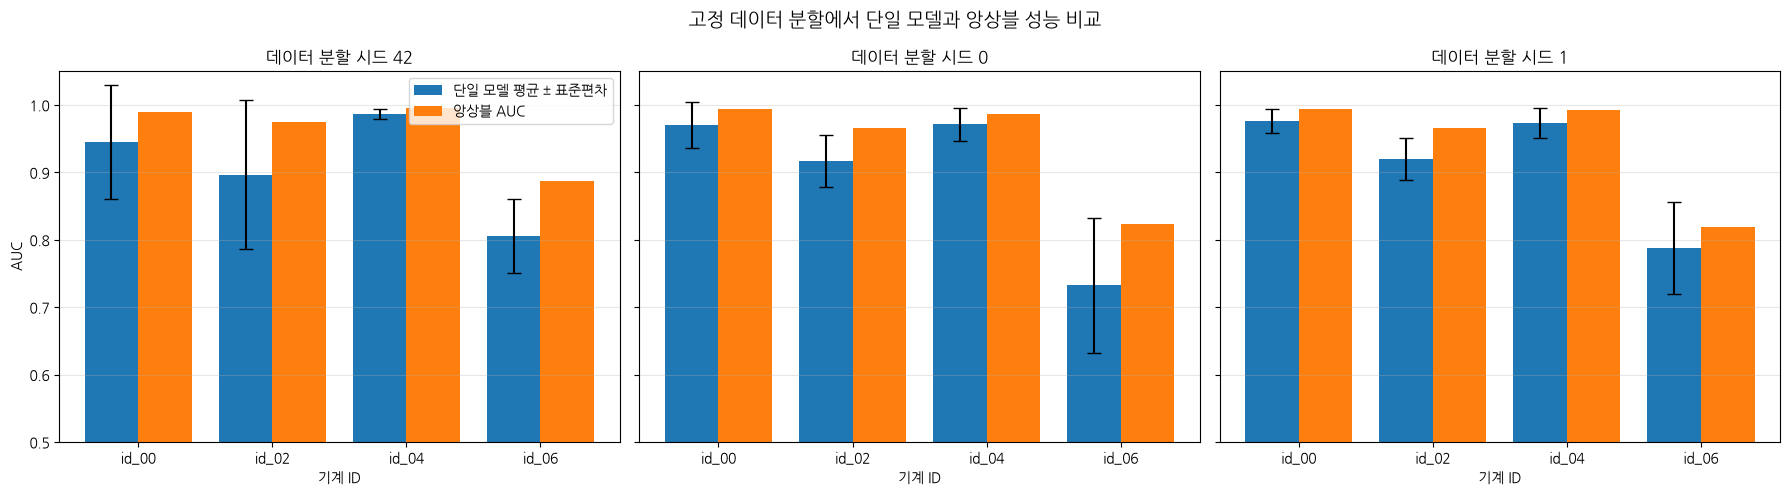

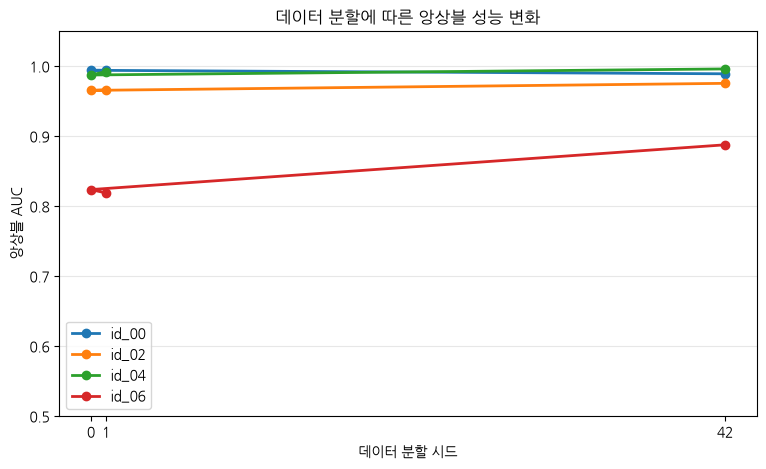

In [4]:
## [3] split별 단일 평균·편차와 앙상블 AUC 시각화
# 각 패널은 하나의 고정 split이며, 막대는 단일 평균과 앙상블을 비교한다.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
xpos = np.arange(len(MACHINES))

for plot_idx in range(len(SPLIT_SEEDS)):
    split_seed = SPLIT_SEEDS[plot_idx]
    single_means = []
    single_stds = []
    ensemble_aucs = []

    for machine in MACHINES:
        result = ensemble_results[split_seed][machine]
        single_means.append(result['single_mean'])
        single_stds.append(result['single_std'])
        ensemble_aucs.append(result['ensemble_auc'])

    axes[plot_idx].bar(
        xpos-0.2, single_means, width=0.4, yerr=single_stds,
        capsize=5, label='단일 모델 평균 ± 표준편차')
    axes[plot_idx].bar(
        xpos+0.2, ensemble_aucs, width=0.4, label='앙상블 AUC')
    axes[plot_idx].set_title(f'데이터 분할 시드 {split_seed}')
    axes[plot_idx].set_xticks(xpos, MACHINES)
    axes[plot_idx].set_ylim(0.5, 1.05)
    axes[plot_idx].set_xlabel('기계 ID')
    axes[plot_idx].grid(axis='y', alpha=0.3)

axes[0].set_ylabel('AUC')
axes[0].legend()
plt.suptitle('고정 데이터 분할에서 단일 모델과 앙상블 성능 비교', fontsize=14)
plt.tight_layout()
plt.show()

# split을 바꿨을 때 앙상블 AUC가 얼마나 흔들리는지 기계별 선으로 확인한다.
plt.figure(figsize=(9, 5))
for machine in MACHINES:
    split_ensemble_aucs = []
    for split_seed in SPLIT_SEEDS:
        split_ensemble_aucs.append(
            ensemble_results[split_seed][machine]['ensemble_auc'])
    plt.plot(
        SPLIT_SEEDS, split_ensemble_aucs, marker='o',
        linewidth=2, label=machine)

plt.xticks(SPLIT_SEEDS)
plt.ylim(0.5, 1.05)
plt.xlabel('데이터 분할 시드')
plt.ylabel('앙상블 AUC')
plt.title('데이터 분할에 따른 앙상블 성능 변화')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()


In [ ]:
## [4] README용 split 42 대표 앙상블 그래프 저장
# CUDA 재실행 오차로 README 수치가 바뀌지 않도록 #8에서 승인된 split 42 결과를 사용한다.
README_SINGLE_MEAN = [0.9231, 0.8813, 0.9751, 0.7942]
README_SINGLE_STD = [0.1129, 0.1031, 0.0245, 0.0521]
README_ENSEMBLE_AUC = [0.9815, 0.9628, 0.9981, 0.8890]

xpos = np.arange(len(MACHINES))
plt.figure(figsize=(9, 5))
plt.bar(
    xpos-0.2, README_SINGLE_MEAN, width=0.4, yerr=README_SINGLE_STD,
    capsize=5, label='단일 모델 평균 ± 표준편차')
plt.bar(xpos+0.2, README_ENSEMBLE_AUC, width=0.4, label='앙상블 AUC')
plt.xticks(xpos, MACHINES)
plt.ylim(0.5, 1.05)
plt.xlabel('기계 ID')
plt.ylabel('AUC')
plt.title('단일 모델과 앙상블 성능 비교 — 데이터 분할 시드 42')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.savefig('../assets/single_vs_ensemble.png', dpi=120, bbox_inches='tight')
plt.show()


## 결과 해석

| split seed | 기계 | 단일 모델 평균 ± 표준편차 | 앙상블 AUC |
|:----------:|:----:|:---------------------------:|:-----------:|
| 42 | id_00 | 0.9231 ± 0.1129 | **0.9815** |
| 42 | id_02 | 0.8813 ± 0.1031 | **0.9628** |
| 42 | id_04 | 0.9751 ± 0.0245 | **0.9981** |
| 42 | id_06 | 0.7942 ± 0.0521 | **0.8890** |
| 0 | id_00 | 0.9668 ± 0.0330 | **0.9932** |
| 0 | id_02 | 0.9108 ± 0.0455 | **0.9676** |
| 0 | id_04 | 0.9653 ± 0.0356 | **0.9876** |
| 0 | id_06 | 0.7656 ± 0.0700 | **0.8153** |
| 1 | id_00 | 0.9737 ± 0.0201 | **0.9928** |
| 1 | id_02 | 0.9318 ± 0.0258 | **0.9720** |
| 1 | id_04 | 0.9699 ± 0.0280 | **0.9918** |
| 1 | id_06 | 0.7547 ± 0.0797 | **0.8329** |

### 데이터 분할 3개의 앙상블 안정성

| 기계 | 앙상블 평균 ± 표준편차 |
|:----:|:------------------------:|
| id_00 | **0.9892 ± 0.0054** |
| id_02 | **0.9675 ± 0.0038** |
| id_04 | **0.9925 ± 0.0043** |
| id_06 | **0.8457 ± 0.0314** |

### 판정

- split 42의 모델 seed 4는 id_00 0.6976, id_02 0.6928로 급락했지만 앙상블은 0.9815/0.9628로 회복했다.
- 모든 split·기계에서 앙상블 AUC가 단일 모델 5개의 평균보다 높았다.
- id_00/02/04 앙상블은 split을 바꿔도 표준편차가 0.006 이하로 안정적이다. 따라서 이 기계들의 큰 흔들림은 모델 초기값 영향이 주요 원인이며 앙상블이 효과적인 해결책이다.
- id_06도 앙상블로 개선됐지만 split 간 표준편차가 0.0314로 상대적으로 크다. id_06은 모델 초기값 외에 데이터 분할 민감도도 남아 있다.
- 이 실험에서는 test 결과를 이용한 기계별 방법 라우팅을 결정하지 않았다.
- IDClassifier 하나는 약 10.09 MiB이고 5개 가중치는 약 50.46 MiB다. 추론 연산량은 약 5배이므로 실제 배포 전 CPU 지연시간 측정이 필요하다.
